# Leveraged ETFs, daily compounding and volatility drag

**Why does a daily 3× leveraged product not deliver 3× the long-run return of its index?**

This notebook is the reproducible analysis behind the article [*Why 3× Daily Leverage Is Not 3× Long-Term Return*](https://dvirross.com/quant-research/notes/why-3x-daily-leverage-is-not-3x-long-term-return) on dvirross.com. It is meant to be readable without any prior context: every assumption is stated, every figure is generated by a cell below, and the real-data section is clearly separated from the synthetic analysis.

**What it covers**

1. A two-day arithmetic example, with a closed-form formula for the shortfall.
2. Daily compounding versus "just multiply the cumulative return by L".
3. Path dependence: the same index return, very different leveraged outcomes.
4. A volatility experiment with explicit drift and volatility assumptions.
5. How expected growth depends on the leverage level.
6. A Monte Carlo distribution of terminal outcomes for 1× and idealized 3× exposure.
7. A real two-session QQQ/TQQQ/SQQQ round trip (June 2024) from a committed data snapshot, clearly labelled as one selected illustration.

**Source material.** This notebook reuses and upgrades ideas from three earlier Colab notebooks by the author (not included in this repository):

* `leverage.ipynb`: simulated daily returns, 1× versus 3× cumulative paths, repeated draws, a function over mean, volatility and horizon, and a (very slow) Monte Carlo average;
* `leverage-testing.ipynb`: QQQ/TQQQ/SQQQ closing prices and a search for short "fall then rebound" sequences (the source of the real example in Section 7);
* `leverage-and-origin-weighting.ipynb`: paired underlying/leveraged tickers and a daily-weighted blend of the two. It is deliberately **not** used here (see the final section).

**Scope and caution.** Everything below is an educational illustration of mathematics. It is not investment advice, it does not forecast returns, and the simulated numbers depend entirely on the stated assumptions. The idealized leveraged product ignores fees, financing costs, tracking error and fund structure.

## 0. Setup

Only NumPy, pandas and Matplotlib are needed for the synthetic analysis. The real-data example reads a committed CSV, so the notebook runs offline; `yfinance` is imported only inside an optional validation cell that is skipped when data cannot be downloaded.

All randomness comes from `numpy.random.default_rng` with fixed seeds, so the notebook gives the same numbers every time it runs.

In [1]:
from pathlib import Path
import json
import math

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, FixedLocator, NullFormatter
from IPython.display import display
import plotly.graph_objects as go
import plotly.io as pio

# ---- reproducibility -------------------------------------------------------
SEED = 20261007                       # master seed; every section draws its own child stream
_seeds = np.random.SeedSequence(SEED).spawn(12)
def rng_for(section: int) -> np.random.Generator:
    '''Independent, reproducible random stream for a numbered section.'''
    return np.random.default_rng(_seeds[section])

TRADING_DAYS = 252                    # trading days per year (a standard convention)

print(f"numpy {np.__version__} | pandas {pd.__version__} | matplotlib {mpl.__version__} | seed {SEED}")

# ---- figure export ---------------------------------------------------------
EXPORT_FIGURES = True                 # set False to run without writing files
_here = Path.cwd().resolve()
REPO_ROOT = _here.parent if _here.name == "notebooks" else _here   # works from the repo root or from notebooks/
FIG_DIR = REPO_ROOT / "figures"
SITE_PATH = "figures"
MANIFEST = {}                         # filename -> alt text, caption idea, assumptions

# ---- plotting style (site palette; figures sit on a white card) ------------
BLUE, ORANGE, INK, MUTED, GRID = "#3758d7", "#c96f33", "#142033", "#5d6678", "#e3e6ee"
mpl.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "font.family": "sans-serif", "font.sans-serif": ["Inter", "DejaVu Sans"],
    "font.size": 10.5, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.labelcolor": MUTED, "axes.edgecolor": "#b9bfcc", "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "lines.linewidth": 2.2, "legend.frameon": False, "figure.dpi": 110,
})
pct = FuncFormatter(lambda v, _: f"{v:.0%}")
mult = FuncFormatter(lambda v, _: f"{v:g}×")

def save_figure(fig, name, alt, caption, assumptions):
    '''Write a 200-dpi PNG to the site assets folder and record its metadata.'''
    MANIFEST[name] = {"file": f"{SITE_PATH}/{name}", "alt": alt, "caption": caption, "assumptions": assumptions}
    if EXPORT_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / name, dpi=200, bbox_inches="tight", pad_inches=0.2)
    plt.show()

def save_plotly(fig, name, alt, caption, assumptions, size=(1100, 520)):
    '''Export an interactive Plotly figure for the website: a JSON spec (figures/<name>.json) that plotly.js renders in the
    browser, plus a static PNG fallback (figures/<name>.png) when a Chrome/Chromium is available for kaleido.'''
    spec = json.loads(pio.to_json(fig))
    spec.get("layout", {}).pop("template", None)                      # keep the spec small and theme-independent
    MANIFEST[name] = {"spec": f"{SITE_PATH}/{name}.json", "static": f"{SITE_PATH}/{name}.png", "alt": alt, "caption": caption, "assumptions": assumptions}
    if EXPORT_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        (FIG_DIR / f"{name}.json").write_text(json.dumps(spec, separators=(",", ":"), ensure_ascii=False) + "\n", encoding="utf-8")
        try:
            pio.write_image(fig, str(FIG_DIR / f"{name}.png"), width=size[0], height=size[1], scale=2)
        except Exception as exc:                                       # kaleido needs Chrome; the JSON is the primary artifact
            print(f"Static PNG not written for {name} ({type(exc).__name__}); the interactive JSON spec was exported.")

numpy 2.5.3 | pandas 3.0.6 | matplotlib 3.11.2 | seed 20261007


## 1. The two-day example

Start with the simplest possible case, before any market data or simulation.

Suppose an index starts at **100**. On day 1 it falls **10 %**, to 90. To get back to 100 it must then rise by exactly $\tfrac{100}{90}-1 \approx 11.1\,\%$ on day 2. The index ends exactly where it started.

A product that delivers **3× the index's return each day** behaves differently:

* day 1: $3 \times (-10\,\%) = -30\,\%$, so 100 becomes 70;
* day 2: $3 \times (+11.1\,\%) = +33.3\,\%$, so 70 becomes 93.3.

The index is back to its start, but the 3× product is down 6.7 %. Nothing unusual happened: percentage changes are applied to the *current* value, so a bigger loss leaves a smaller base to recover from.

**Closed form.** Let the index fall by a fraction $a$ and then rise by exactly $\tfrac{a}{1-a}$, so that it returns to its start. A daily $L\times$ product ends at

$$(1-La)\Bigl(1+L\tfrac{a}{1-a}\Bigr) \;=\; 1-\frac{L(L-1)\,a^{2}}{1-a}.$$

For $L=1$ the loss is zero, as it should be. For $L=3$ and $a=10\,\%$ it is $1-6(0.01)/0.9 = 0.9333$. The shortfall grows with the **square** of the size of the move, which is why it is small for quiet markets and large for turbulent ones.

The effect is not a one-way street. Two *up* days of 10 % each give the index +21 % and the 3× product $1.3^2-1=+69\,\%$, which is *more* than $3\times 21\,\%=63\,\%$. Compounding works for leveraged products when moves are consistent in one direction and against them when direction keeps reversing. The cell below computes all three cases.

In [2]:
def daily_leveraged_path(returns, leverage):
    '''Value path of an idealized daily-reset product that starts at 1.
    returns: simple daily returns of the underlying (decimals, e.g. 0.01 = 1 %).
    No fees, financing or tracking error; the value is floored at zero (a fund cannot go negative).'''
    growth = np.maximum(1.0 + leverage * np.asarray(returns, dtype=float), 0.0)
    return np.concatenate([[1.0], np.cumprod(growth)])

a, L = 0.10, 3
cases = {
    "Fall 10 %, then rebound to start": [-a, a / (1 - a)],
    "Two rises of 10 %":                [0.10, 0.10],
    "Rise 10 %, then fall 10 %":        [0.10, -0.10],
}
rows = []
for label, r in cases.items():
    idx_total = np.prod(1 + np.array(r)) - 1
    lev_total = daily_leveraged_path(r, L)[-1] - 1
    rows.append({"Two-day sequence": label,
                 "Index return": idx_total,
                 f"{L}× of the index return": L * idx_total,
                 f"Daily {L}× product": lev_total,
                 "Gap (product minus 3× index)": lev_total - L * idx_total})
two_day = pd.DataFrame(rows).set_index("Two-day sequence")
display(two_day.style.format("{:+.2%}"))

# check the closed form 1 - L(L-1)a^2/(1-a) against the direct calculation
for L_ in (1, 2, 3, 4):
    direct = daily_leveraged_path([-a, a / (1 - a)], L_)[-1]
    closed = 1 - L_ * (L_ - 1) * a**2 / (1 - a)
    assert abs(direct - closed) < 1e-12, (L_, direct, closed)
print("Closed-form shortfall formula verified for L = 1, 2, 3, 4.")

,Index return,3× of the index return,Daily 3× product,Gap (product minus 3× index)
Two-day sequence,,,,
"Fall 10 %, then rebound to start",+0.00%,+0.00%,-6.67%,-6.67%
Two rises of 10 %,+21.00%,+63.00%,+69.00%,+6.00%
"Rise 10 %, then fall 10 %",-1.00%,-3.00%,-9.00%,-6.00%


Closed-form shortfall formula verified for L = 1, 2, 3, 4.


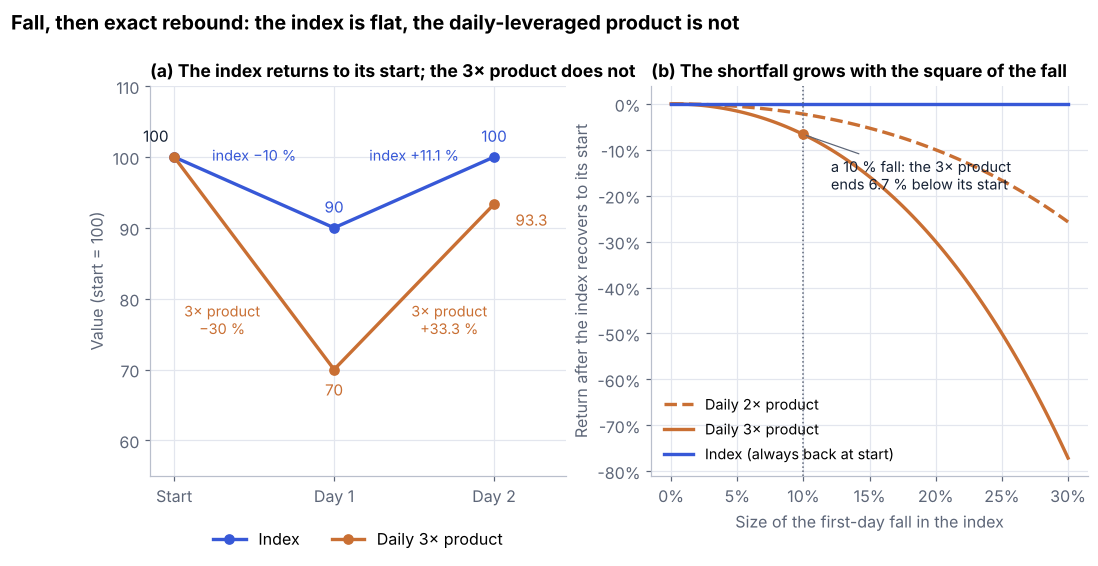

In [3]:
# Figure 1: the two-day example, and how the shortfall grows with the size of the fall.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6), gridspec_kw={"width_ratios": [1, 1.05]})

days = [0, 1, 2]
idx = 100 * np.concatenate([[1], np.cumprod(1 + np.array([-a, a / (1 - a)]))])
lev = 100 * daily_leveraged_path([-a, a / (1 - a)], 3)
ax1.plot(days, idx, "-o", color=BLUE, label="Index")
ax1.plot(days, lev, "-o", color=ORANGE, label="Daily 3× product")
ax1.annotate("100", (0, 100), textcoords="offset points", xytext=(-12, 10), ha="center", color=INK, fontsize=10)
ax1.annotate("90", (1, 90), textcoords="offset points", xytext=(0, 10), ha="center", color=BLUE, fontsize=10)
ax1.annotate("100", (2, 100), textcoords="offset points", xytext=(0, 10), ha="center", color=BLUE, fontsize=10)
ax1.annotate("70", (1, 70), textcoords="offset points", xytext=(0, -17), ha="center", color=ORANGE, fontsize=10)
ax1.annotate("93.3", (2, lev[2]), textcoords="offset points", xytext=(14, -14), ha="left", color=ORANGE, fontsize=10)
ax1.text(0.5, 99.0, "index −10 %", ha="center", va="bottom", fontsize=9.5, color=BLUE)
ax1.text(1.5, 99.0, "index +11.1 %", ha="center", va="bottom", fontsize=9.5, color=BLUE)
ax1.text(0.3, 77, "3× product\n−30 %", ha="center", va="center", fontsize=9.5, color=ORANGE)
ax1.text(1.72, 77, "3× product\n+33.3 %", ha="center", va="center", fontsize=9.5, color=ORANGE)
ax1.set_xticks(days); ax1.set_xticklabels(["Start", "Day 1", "Day 2"])
ax1.set_xlim(-0.15, 2.45); ax1.set_ylim(55, 110); ax1.set_ylabel("Value (start = 100)")
ax1.set_title("(a) The index returns to its start; the 3× product does not")
ax1.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=2)

drop = np.linspace(0, 0.30, 121)
for L_, col, ls in ((2, ORANGE, "--"), (3, ORANGE, "-")):
    end = 1 - L_ * (L_ - 1) * drop**2 / (1 - drop)
    ax2.plot(drop, end - 1, color=col, ls=ls, label=f"Daily {L_}× product")
ax2.plot(drop, np.zeros_like(drop), color=BLUE, label="Index (always back at start)")
ax2.axvline(a, color=MUTED, lw=1, ls=":")
ax2.plot([a], [1 - 6 * a**2 / (1 - a) - 1], "o", color=ORANGE, ms=6)
ax2.annotate("a 10 % fall: the 3× product\nends 6.7 % below its start", (a, 1 - 6 * a**2 / (1 - a) - 1), textcoords="offset points", xytext=(18, -36), fontsize=9.5, color=INK,
             arrowprops=dict(arrowstyle="-", color=MUTED, lw=0.8))
ax2.xaxis.set_major_formatter(pct); ax2.yaxis.set_major_formatter(pct)
ax2.set_xlabel("Size of the first-day fall in the index"); ax2.set_ylabel("Return after the index recovers to its start")
ax2.set_title("(b) The shortfall grows with the square of the fall")
ax2.legend(loc="lower left", fontsize=9.5)
fig.suptitle("Fall, then exact rebound: the index is flat, the daily-leveraged product is not", x=0.01, ha="left", fontsize=13, fontweight="bold", y=1.03)
save_figure(fig, "01-two-day-example.png",
    alt="Two charts. Left: an index falls from 100 to 90 and returns to 100 while a daily 3× product falls from 100 to 70 and recovers only to 93.3. Right: the loss of the 2× and 3× products after the index recovers to its start grows quickly as the first-day fall gets larger.",
    caption="Two-day example: after a 10 % fall and the exact 11.1 % rebound, the index is flat but a daily 3× product is down 6.7 %; the shortfall grows with the square of the fall.",
    assumptions="Idealized daily-reset leverage, no fees or financing; arithmetic only, no simulation.")

## 2. Daily compounding is not "multiply the cumulative return by L"

For daily simple returns $r_1,\dots,r_T$ of the underlying:

$$V_T = V_0\prod_{t=1}^{T}(1+r_t) \qquad\text{(unleveraged)}$$

$$V_T^{(L)} = V_0\prod_{t=1}^{T}(1+L\,r_t) \qquad\text{(idealized daily } L\times\text{ leverage)}$$

Two things people often assume, both wrong in general:

* $V_T^{(L)}/V_0 - 1 \;=\; L\,(V_T/V_0-1)$, that is, "the long-run return is $L$ times the index's long-run return";
* $V_T^{(L)}/V_0 \;=\; (V_T/V_0)^L$, that is, "the leveraged value is the index growth factor raised to the power $L$".

**Why they fail.** Take logarithms. Using $\ln(1+x)\approx x - x^2/2$ for small $x$,

$$\ln\frac{V_T^{(L)}}{V_0} = \sum_t \ln(1+Lr_t) \;\approx\; L\sum_t r_t \;-\; \frac{L^2}{2}\sum_t r_t^2,
\qquad
\ln\frac{V_T}{V_0} \approx \sum_t r_t - \tfrac12\sum_t r_t^2 .$$

So $\ln V_T^{(L)} - L\ln V_T \approx -\tfrac{L(L-1)}{2}\sum_t r_t^2$. The leveraged log-growth falls short of $L$ times the index's log-growth by an amount that depends on the **sum of squared daily returns**, i.e. on realized variance. This is the "volatility drag" (also called variance drain). For $L=3$ the gap is $-3\sum_t r_t^2$.

The next cell checks all of this on one seeded year of simulated returns, and then on 2,000 simulated years.

In [4]:
# One year of simulated daily returns: arithmetic mean 8 % a year, volatility 20 % a year (explicit, simple returns).
MU_ANN, SIG_ANN = 0.08, 0.20
mu_d, sig_d = MU_ANN / TRADING_DAYS, SIG_ANN / math.sqrt(TRADING_DAYS)

r = mu_d + sig_d * rng_for(2).standard_normal(TRADING_DAYS)

cum_1x      = np.prod(1 + r) - 1
naive_3x    = 3 * cum_1x                       # "multiply the long-run return by 3"
power_3x    = (1 + cum_1x) ** 3 - 1            # "cube the growth factor"
ideal_3x    = np.prod(1 + 3 * r) - 1           # what daily 3× compounding actually gives
print(f"Index return over the year:                {cum_1x:+.2%}")
print(f"3 × index return (wrong):                  {naive_3x:+.2%}")
print(f"(1 + index return)^3 - 1 (also wrong):     {power_3x:+.2%}")
print(f"Daily 3× compounding (idealized):          {ideal_3x:+.2%}")

# the log-growth gap against its second-order approximation  -3 * sum(r^2)
exact_gap  = np.log1p(3 * r).sum() - 3 * np.log1p(r).sum()
approx_gap = -3 * np.sum(r**2)
print(f"\nln V3 - 3 ln V1: exact {exact_gap:+.4f}, approximation -3·Σr² = {approx_gap:+.4f}")

Index return over the year:                -16.38%
3 × index return (wrong):                  -49.15%
(1 + index return)^3 - 1 (also wrong):     -41.54%
Daily 3× compounding (idealized):          -48.75%

ln V3 - 3 ln V1: exact -0.1317, approximation -3·Σr² = -0.1315


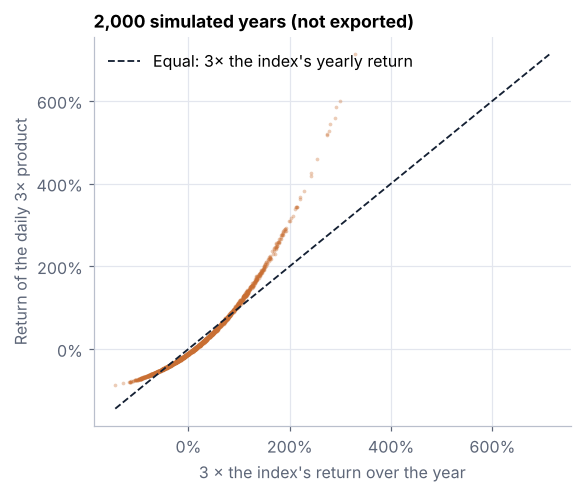

Share of simulated years where the daily 3× product ends below 3 × the index return: 64%
Mean of (daily 3× return minus 3 × index return): +3.0%
Median of the same difference:                    -6.2%


In [5]:
# 2,000 independent simulated years: daily 3× result versus "3 × the index's yearly return".
n_years = 2000
R = mu_d + sig_d * rng_for(2).standard_normal((n_years, TRADING_DAYS))
idx_year = np.prod(1 + R, axis=1) - 1
lev_year = np.prod(1 + 3 * R, axis=1) - 1

fig, ax = plt.subplots(figsize=(5.6, 4.6))
ax.scatter(3 * idx_year, lev_year, s=6, alpha=0.35, color=ORANGE, linewidths=0)
lim = np.array([min((3 * idx_year).min(), lev_year.min()), max((3 * idx_year).max(), lev_year.max())])
ax.plot(lim, lim, color=INK, lw=1.2, ls="--", label="Equal: 3× the index's yearly return")
ax.xaxis.set_major_formatter(pct); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("3 × the index's return over the year"); ax.set_ylabel("Return of the daily 3× product")
ax.set_title("2,000 simulated years (not exported)"); ax.legend(loc="upper left")
plt.show()

below = np.mean(lev_year < 3 * idx_year)
print(f"Share of simulated years where the daily 3× product ends below 3 × the index return: {below:.0%}")
print(f"Mean of (daily 3× return minus 3 × index return): {np.mean(lev_year - 3 * idx_year):+.1%}")
print(f"Median of the same difference:                    {np.median(lev_year - 3 * idx_year):+.1%}")

**Reading the scatter.** Points do not sit on the dashed line, so daily 3× compounding is *not* the same as multiplying the yearly return by 3. In this simulation the daily product lags "3× the index's return" in years when the index return is moderate (roughly between −20 % and +20 %), and lands *above* it in years of very large index gains (compounding in a consistent direction helps) and in years of very large index losses (a compounded loss is cushioned, while a plain 3× multiple would overshoot toward −100 % or beyond). The relationship is path-dependent and non-linear, not a uniform haircut. The exact crossover points depend on the volatility and drift assumed here.

## 3. Path dependence: the same index return, different paths

Compounding means the *order* of returns matters, not just their total. Below, three 20-day sequences of daily index returns are built so that **all three end at exactly +10 %**:

* **A, steady climb:** the same small gain every day;
* **B, choppy:** alternating +5 % days and small losses;
* **C, slide then rebound:** ten days of −3 %, then ten larger gains.

They are synthetic by design: the point is the mechanism, and a constructed example is easier to read than a hand-picked historical episode.

In [6]:
TARGET = 1.10          # every path ends exactly at +10 % for the index
N = 20

# A: constant daily gain
rA = np.full(N, TARGET ** (1 / N) - 1)

# B: alternating +5 % and a loss chosen so that each pair compounds to the same factor
pair = TARGET ** (2 / N)
up = 0.05
rB = np.tile([up, pair / (1 + up) - 1], N // 2)

# C: ten days of -3 %, then ten equal gains that bring the index to the target
slide = np.full(N // 2, -0.03)
rebound = np.full(N // 2, (TARGET / np.prod(1 + slide)) ** (1 / (N // 2)) - 1)
rC = np.concatenate([slide, rebound])

paths = {"A  Steady climb": rA, "B  Choppy": rB, "C  Slide, then rebound": rC}
summary = []
for name, rr in paths.items():
    idx_end = np.prod(1 + rr)
    assert abs(idx_end - TARGET) < 1e-12
    end3 = daily_leveraged_path(rr, 3)[-1]
    summary.append({"Path": name, "Index return": idx_end - 1,
                    "3 × index return": 3 * (idx_end - 1),
                    "Daily 3× product": end3 - 1,
                    "Sum of squared daily returns": np.sum(rr**2)})
path_table = pd.DataFrame(summary).set_index("Path")
display(path_table.style.format({"Index return": "{:+.1%}", "3 × index return": "{:+.1%}",
                                 "Daily 3× product": "{:+.1%}", "Sum of squared daily returns": "{:.4f}"}))

,Index return,3 × index return,Daily 3× product,Sum of squared daily returns
Path,,,,
A Steady climb,+10.0%,+30.0%,+32.9%,0.0005
B Choppy,+10.0%,+30.0%,+18.6%,0.0398
"C Slide, then rebound",+10.0%,+30.0%,+23.6%,0.0256


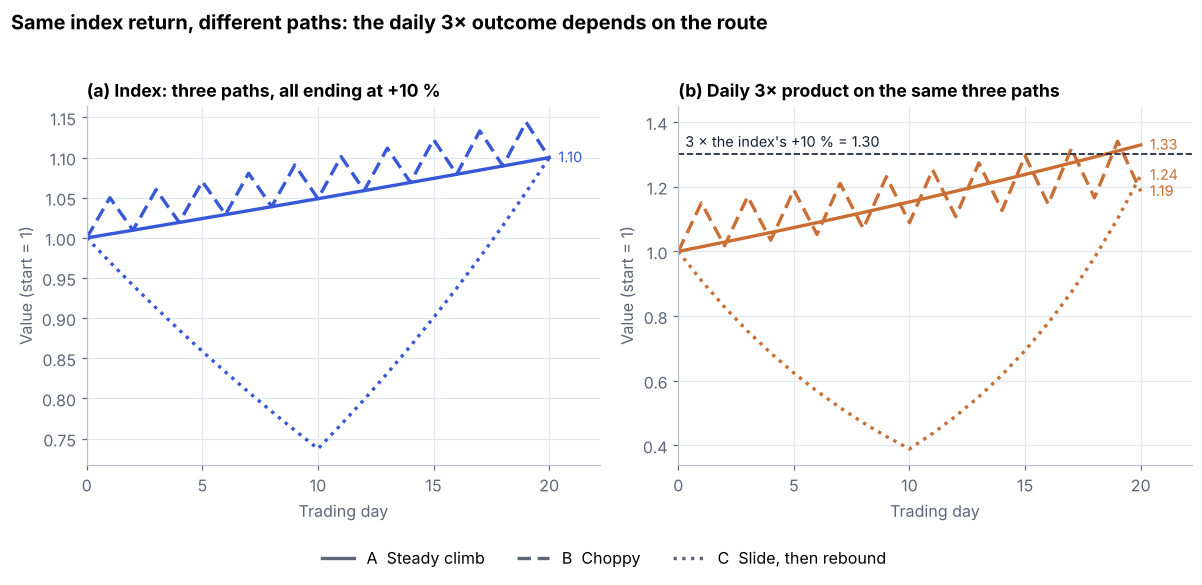

In [7]:
# Figure 2
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.0), sharex=True)
styles = {"A  Steady climb": "-", "B  Choppy": (0, (4, 2)), "C  Slide, then rebound": (0, (1, 1.6))}
x = np.arange(N + 1)
lev_paths = {name: daily_leveraged_path(rr, 3) for name, rr in paths.items()}
for name, rr in paths.items():
    ax1.plot(x, np.concatenate([[1], np.cumprod(1 + rr)]), color=BLUE, ls=styles[name], label=name)
    ax2.plot(x, lev_paths[name], color=ORANGE, ls=styles[name], label=name)
ax2.axhline(1.30, color=INK, lw=1.1, ls="--")
ax2.annotate("3 × the index's +10 % = 1.30", (0.3, 1.30), textcoords="offset points", xytext=(0, 5), ha="left", fontsize=9.5, color=INK)
for ax, ttl in ((ax1, "(a) Index: three paths, all ending at +10 %"), (ax2, "(b) Daily 3× product on the same three paths")):
    ax.set_title(ttl); ax.set_xlabel("Trading day"); ax.set_xlim(0, N + 2.2); ax.set_xticks([0, 5, 10, 15, 20])
ax1.set_ylabel("Value (start = 1)"); ax2.set_ylabel("Value (start = 1)")
lo = min(p.min() for p in lev_paths.values())
ax2.set_ylim(lo - 0.05, 1.45)
for name in paths:
    end3 = lev_paths[name][-1]
    ax2.annotate(f"{end3:.2f}", (N, end3), textcoords="offset points", xytext=(6, -3), fontsize=9.5, color=ORANGE)
ax1.annotate("1.10", (N, 1.10), textcoords="offset points", xytext=(6, -3), fontsize=9.5, color=BLUE)
handles = [plt.Line2D([], [], color=MUTED, lw=2.2, ls=styles[n]) for n in paths]
fig.legend(handles, list(paths), loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Same index return, different paths: the daily 3× outcome depends on the route", x=0.01, ha="left", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout(rect=(0, 0.06, 1, 1))
save_figure(fig, "02-same-index-different-paths.png",
    alt="Two charts over 20 trading days. Left: three index paths, a steady climb, a choppy path and a slide followed by a rebound, all ending at 1.10. Right: the daily 3× product on the same paths ends at different values, about 1.33 for the steady climb, 1.24 for the slide and rebound and 1.19 for the choppy path, against a dashed line at 1.30 for three times the index's 10 percent gain.",
    caption="Three index paths with the same +10 % return: a daily 3× product ends at different values depending on the path, and none of them equals 3 × 10 % = 30 %.",
    assumptions="Synthetic 20-day return sequences constructed to end at exactly +10 % for the index; idealized daily 3× leverage, no fees.")

**Interpretation.** All three paths give the index exactly +10 %, and all three leveraged outcomes are different, and different from the "obvious" +30 %. The steady climb ends slightly *above* the naive 30 % (consistent gains compound in the product's favour). The choppy path loses ground every time direction flips, and the slide-then-rebound path takes its losses first and then has a smaller base to recover from; both end clearly below. The last column of the table shows the common thread: the more squared-return "wiggle" for the same net index return, the larger the drag. Here the choppy path has the largest sum of squared returns and the lowest outcome.

## 4. Volatility experiment

**Setup (explicit assumptions).**

* Daily simple returns are i.i.d. Normal: $r_t = \mu_d + \sigma_d z_t$ with $z_t\sim N(0,1)$. This is a deliberately simple benchmark, not a claim that markets are Normal (fat tails are tested in Section 6).
* The **arithmetic** expected return is fixed at $\mu = 8\,\%$ per year, so $\mu_d=\mu/252$. Only volatility changes: **10 %, 20 %, 40 %, 60 %** per year, so $\sigma_d=\sigma/\sqrt{252}$.
* Horizon 5 years = 1,260 trading days. Leverage $L\in\{1,3\}$, idealized daily reset.
* Within one panel the 1× and 3× paths use the *same* random shocks $z_t$, and every panel uses the same $z_t$ at a different scale, so differences come from volatility and leverage, not from luck of the draw.
* Dotted lines show the median wealth across 5,000 seeded paths, so the single seeded path is not mistaken for the typical outcome.

**Terminology that matters here.**

* The **arithmetic mean** return is the simple average of daily returns. Leverage multiplies it by $L$: the average daily return of an idealized 3× product is 3 times the index's.
* The **geometric (compound) growth rate** is what the money actually grows at per period. For small moves it is approximately $\mu-\sigma^2/2$ for the index and $L\mu-L^2\sigma^2/2$ for the $L\times$ product, so leverage multiplies the drift by $L$ but the variance penalty by $L^2$.
* **Volatility drag** is the $\sigma^2/2$ (or $L^2\sigma^2/2$) term: the gap between the arithmetic and the geometric rate. It is a statement about compounding, not a fee and not a property specific to ETFs.

In [8]:
VOL_LEVELS = [0.10, 0.20, 0.40, 0.60]
YEARS, T = 5, 5 * TRADING_DAYS
N_BAND = 5_000                       # paths used for the dotted median curves

z_single = rng_for(3).standard_normal(T)          # shared shocks for the single seeded path
z_band = rng_for(4).standard_normal((N_BAND, T))  # shared shocks for the median curves

def wealth_paths(shocks, sigma_ann, leverage, mu_ann=MU_ANN):
    '''Wealth multiples (start = 1) for idealized daily L× exposure; works on 1-D or 2-D shock arrays.'''
    r = mu_ann / TRADING_DAYS + sigma_ann / math.sqrt(TRADING_DAYS) * shocks
    growth = np.maximum(1 + leverage * r, 0.0)
    return np.cumprod(growth, axis=-1)

vol_rows, panels = [], {}
for s_ in VOL_LEVELS:
    w1, w3 = wealth_paths(z_single, s_, 1), wealth_paths(z_single, s_, 3)
    m1 = np.median(wealth_paths(z_band, s_, 1), axis=0)
    m3 = np.median(wealth_paths(z_band, s_, 3), axis=0)
    panels[s_] = (w1, w3, m1, m3)
    mu_d_ = MU_ANN / TRADING_DAYS
    vol_rows.append({"Volatility (a year)": s_,
                     "Arithmetic mean daily return, 1×": mu_d_,
                     "Arithmetic mean daily return, 3×": 3 * mu_d_,
                     "Typical compound growth a year, 1× (from median)": m1[-1] ** (1 / YEARS) - 1,
                     "Typical compound growth a year, 3× (from median)": m3[-1] ** (1 / YEARS) - 1,
                     "Approx. g(1) = μ − σ²/2": MU_ANN - 0.5 * s_**2,
                     "Approx. g(3) = 3μ − 9σ²/2": 3 * MU_ANN - 4.5 * s_**2,
                     "Median final value, 1×": m1[-1], "Median final value, 3×": m3[-1],
                     "One seeded path: final 1×": w1[-1], "One seeded path: final 3×": w3[-1]})
vol_table = pd.DataFrame(vol_rows).set_index("Volatility (a year)")
vol_table.index = [f"{v:.0%}" for v in vol_table.index]
display(vol_table.style.format({"Arithmetic mean daily return, 1×": "{:.4%}", "Arithmetic mean daily return, 3×": "{:.4%}",
                                "Typical compound growth a year, 1× (from median)": "{:+.1%}", "Typical compound growth a year, 3× (from median)": "{:+.1%}",
                                "Approx. g(1) = μ − σ²/2": "{:+.1%}", "Approx. g(3) = 3μ − 9σ²/2": "{:+.1%}"}, precision=2))

,"Arithmetic mean daily return, 1×","Arithmetic mean daily return, 3×","Typical compound growth a year, 1× (from median)","Typical compound growth a year, 3× (from median)",Approx. g(1) = μ − σ²/2,Approx. g(3) = 3μ − 9σ²/2,"Median final value, 1×","Median final value, 3×",One seeded path: final 1×,One seeded path: final 3×
10%,0.0317%,0.0952%,+7.7%,+21.4%,+7.5%,+19.5%,1.45,2.63,1.93,6.20
20%,0.0317%,0.0952%,+6.1%,+5.9%,+6.0%,+6.0%,1.34,1.33,2.37,7.57
40%,0.0317%,0.0952%,-0.2%,-38.8%,-0.0%,-48.0%,0.99,0.09,3.12,3.12
60%,0.0317%,0.0952%,-9.8%,-75.8%,-10.0%,-138.0%,0.60,0.00,3.41,0.22


**Reading the table.** The arithmetic mean daily return of the 3× product is always three times the index's, yet the *typical compound growth* (computed from the median of 5,000 paths, and close to the second-order approximation) first matches and then falls far below the index as volatility rises. At 10 % volatility the 3× product compounds well ahead of the index; at 20 % the two are about equal; at 40 % and 60 % the typical compound growth of the 3× product is strongly negative even though its arithmetic mean daily return is positive. The second-order approximation tracks the median-based numbers well at 10 % and 20 % volatility, but overshoots at 40 % and 60 % (a growth rate below −100 % a year is impossible), so the median-based columns are the reliable ones there. The last two columns are one seeded path only: they are shown to connect to the figure, and they are *not* a typical outcome (at 40 % volatility this particular path happens to end with 1× and 3× at the same value).

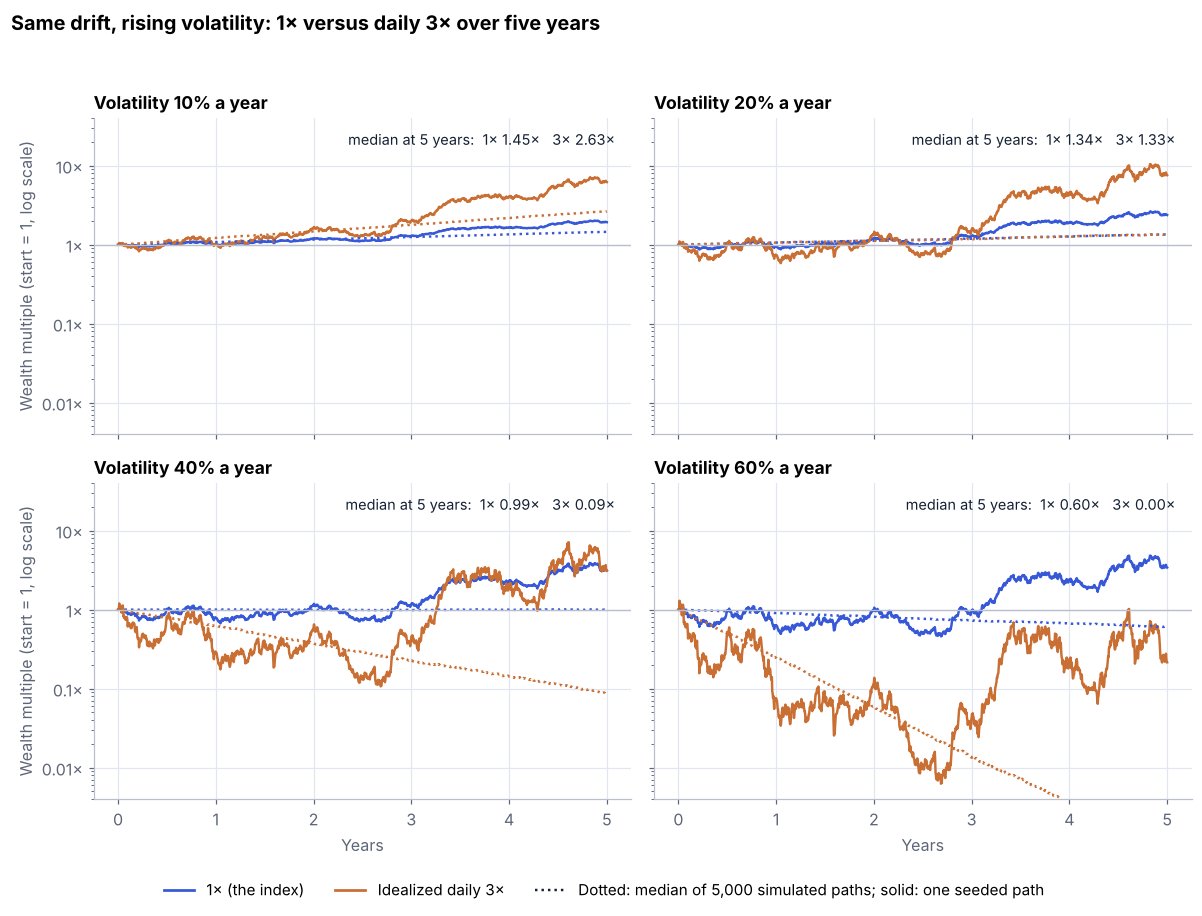

In [9]:
# Figure 3
fig, axes = plt.subplots(2, 2, figsize=(11, 8.2), sharex=True, sharey=True)
t = np.arange(T + 1) / TRADING_DAYS
for ax, s_ in zip(axes.ravel(), VOL_LEVELS):
    w1, w3, m1, m3 = panels[s_]
    ax.plot(t, np.concatenate([[1], w1]), color=BLUE, lw=1.6)
    ax.plot(t, np.concatenate([[1], w3]), color=ORANGE, lw=1.6)
    ax.plot(t, np.concatenate([[1], m1]), color=BLUE, lw=1.6, ls=":")
    ax.plot(t, np.concatenate([[1], m3]), color=ORANGE, lw=1.6, ls=":")
    ax.axhline(1, color="#b9bfcc", lw=0.9)
    ax.set_yscale("log")
    ax.yaxis.set_major_locator(FixedLocator([0.01, 0.1, 1, 10])); ax.yaxis.set_minor_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}×"))
    ax.set_ylim(0.004, 40)
    ax.set_title(f"Volatility {s_:.0%} a year")
    ax.text(0.97, 0.96, f"median at 5 years:  1× {m1[-1]:.2f}×   3× {m3[-1]:.2f}×", transform=ax.transAxes, ha="right", va="top", fontsize=9.5, color=INK)
for ax in axes[1]: ax.set_xlabel("Years")
for ax in axes[:, 0]: ax.set_ylabel("Wealth multiple (start = 1, log scale)")
handles = [plt.Line2D([], [], color=BLUE, lw=1.8), plt.Line2D([], [], color=ORANGE, lw=1.8),
           plt.Line2D([], [], color=INK, lw=1.6, ls=":")]
fig.legend(handles, ["1× (the index)", "Idealized daily 3×", "Dotted: median of 5,000 simulated paths; solid: one seeded path"],
           loc="lower center", ncol=3, bbox_to_anchor=(0.5, -0.005), fontsize=10)
fig.suptitle("Same drift, rising volatility: 1× versus daily 3× over five years", x=0.01, ha="left", fontsize=13, fontweight="bold", y=0.995)
fig.tight_layout(rect=(0, 0.04, 1, 0.97))
save_figure(fig, "03-volatility-comparison.png",
    alt="Four panels for annual volatility of 10, 20, 40 and 60 percent over five years, each showing wealth multiples on a log scale for the index and an idealized daily 3× product, with dotted median curves. At 10 percent volatility the 3× path ends far above the index; at 20 percent the medians are about equal; at 40 and 60 percent the 3× path collapses toward zero while the index stays comparatively close to its start.",
    caption="With the same 8 % arithmetic drift, the idealized daily 3× product pulls well ahead of the index at 10 % volatility, roughly matches its median at 20 %, and falls far behind at 40 % and 60 %. Solid lines: one seeded path; dotted: median of 5,000 paths.",
    assumptions="i.i.d. Normal daily simple returns, arithmetic mean 8 % a year, volatility 10/20/40/60 % a year, 252 trading days, 5 years, idealized daily reset with no costs; common random numbers across panels.")

**Interpretation.** This is not a story of "leveraged products always decay". With the same 8 % arithmetic drift the 3× product wins clearly at 10 % volatility, roughly ties the index's median at 20 %, and loses badly at 40 % and 60 %. What leverage reliably does is change how drift and variance enter: it multiplies the drift by 3 and the variance penalty by 9. Which effect dominates depends on the ratio of drift to variance, which the next section makes precise.

## 5. How growth depends on the leverage level

Under the second-order approximation, the long-run geometric growth rate of an idealized daily $L\times$ product, per year, is

$$g(L) \;\approx\; L\mu - \tfrac12 L^2\sigma^2 ,$$

with $\mu$ the arithmetic mean annual return and $\sigma$ the annual volatility. This is a downward parabola in $L$:

* it is largest at $L^\star=\mu/\sigma^2$ (the leverage that maximizes long-run growth in this model);
* it equals the index's growth at $L=1$ and crosses zero at $L=2\mu/\sigma^2$;
* so $L=3$ has positive long-run growth only if $\mu>1.5\,\sigma^2$, and beats $L=1$ only if $\mu>2\sigma^2$.

With $\sigma=20\,\%$, $\sigma^2=0.04$, so 3× needs $\mu>6\,\%$ to grow at all and $\mu>8\,\%$ to beat the index in typical terms. That is exactly the break-even we saw in the 20 % volatility panel. At $\sigma=40\,\%$ ($\sigma^2=0.16$) it would need $\mu>24\,\%$.

This is a statement about the **typical (median) growth rate**. It says nothing against the arithmetic *expected* terminal value, which for independent daily returns is exactly $(1+L\mu_d)^T$ and rises with $L$ even when the median falls. Mean and median describe very different features of a highly skewed distribution (see Section 6).

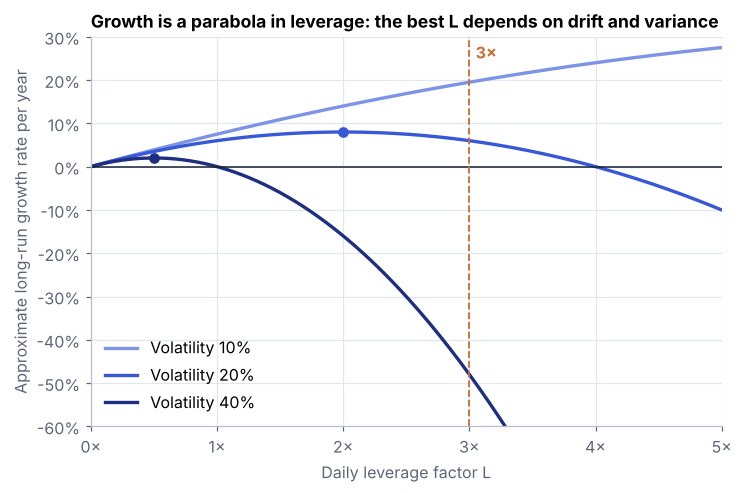

In [10]:
# Figure 6 (optional): approximate long-run growth rate versus leverage level.
mu = MU_ANN
Ls = np.linspace(0, 5, 251)
fig, ax = plt.subplots(figsize=(7.4, 4.6))
shades = {0.10: "#7d93e6", 0.20: BLUE, 0.40: "#1c2f80"}
for s, col in shades.items():
    g = Ls * mu - 0.5 * Ls**2 * s**2
    ax.plot(Ls, g, color=col, label=f"Volatility {s:.0%}")
    Lstar = mu / s**2
    if Lstar <= 5:
        ax.plot([Lstar], [Lstar * mu - 0.5 * Lstar**2 * s**2], "o", color=col, ms=6)
ax.axhline(0, color=INK, lw=1)
ax.axvline(3, color=ORANGE, lw=1.2, ls="--")
ax.text(3.05, 0.25, "3×", color=ORANGE, fontsize=10.5, fontweight="bold")
ax.set_ylim(-0.6, 0.30); ax.set_xlim(0, 5)
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}×")); ax.yaxis.set_major_formatter(pct)
ax.set_xlabel("Daily leverage factor L"); ax.set_ylabel("Approximate long-run growth rate per year")
ax.set_title("Growth is a parabola in leverage: the best L depends on drift and variance")
ax.legend(loc="lower left")
save_figure(fig, "06-growth-rate-vs-leverage.png",
    alt="Line chart of approximate long-run annual growth rate against the daily leverage factor from 0 to 5 times, for annual volatilities of 10, 20 and 40 percent with an 8 percent arithmetic drift. Each curve is a downward parabola; the peak moves left and lower as volatility rises, and at 3 times leverage growth is clearly positive at 10 percent volatility, about 6 percent at 20 percent, and strongly negative at 40 percent.",
    caption="Approximate long-run growth rate versus leverage for a fixed 8 % arithmetic drift: more leverage first helps and then hurts, and the turning point depends on volatility. Dots mark the growth-maximizing leverage μ/σ² where it is within 5×.",
    assumptions="Second-order approximation g(L) = Lμ − ½L²σ² with μ = 8 %, i.i.d. returns, no costs. Optional figure.")

## 6. Monte Carlo distribution of terminal outcomes

**Question.** Over a five-year horizon, what does the *distribution* of final wealth look like for a 1× and an idealized daily 3× position, under the same return process?

**Setup.**

* Base case: i.i.d. Normal daily simple returns, arithmetic mean 8 % a year, volatility 20 % a year, 5 years (1,260 days), idealized daily reset, no costs.
* 100,000 simulated paths, generated in chunks and summarized without storing full paths: terminal wealth is $\exp\bigl(\sum_t\ln(1+Lr_t)\bigr)$, which is exact and fully vectorized.
* If a draw ever produced $1+Lr_t\le 0$ (a one-day loss larger than $1/L$) the product would be wiped out; the code floors it at zero and **counts** such paths so we can see whether the assumption matters.
* Because the base case sits close to the break-even $\mu = 2\sigma^2$ from Section 5, the *median* 1× and 3× outcomes are nearly equal by construction. That is a feature of this particular parameter choice, not a general result; the sensitivity table varies it.

**Measures chosen for this article.**

* *Median* terminal wealth: the typical outcome (half of paths end above it).
* *Mean* terminal wealth: dominated by rare large outcomes; for i.i.d. returns it equals $(1+L\mu_d)^T$ exactly, which we use as a check.
* Quantiles (5th, 25th, 75th, 95th): the spread.
* Probability of ending below the start, and below the 1× outcome on the same path.
* Probability that the 3× product ends below $1+3\,(V_T^{(1)}/V_0-1)$, "3× the index return", on the same path. This is only meaningful when the index return is not very negative (a 3× multiple of a loss larger than 33 % would be below −100 %), so it is reported for the base case and not for the high-volatility rows.

In [11]:
def simulate_terminal(mu_ann, sig_ann, years, leverages=(1, 3), n_paths=100_000, chunk=10_000,
                      seed_seq=None, dist="normal", df=4):
    '''Vectorized Monte Carlo of terminal wealth multiples for idealized daily L× exposure.
    Returns {L: array of terminal wealth}, plus the number of paths with a total-loss day for each L.
    dist = "normal" or "t" (Student-t with `df` degrees of freedom, rescaled to unit variance).'''
    T = int(round(years * TRADING_DAYS))
    mu_d, sig_d = mu_ann / TRADING_DAYS, sig_ann / math.sqrt(TRADING_DAYS)
    rng = np.random.default_rng(seed_seq)
    out = {L: [] for L in leverages}; wiped = {L: 0 for L in leverages}
    for _ in range(n_paths // chunk):
        if dist == "normal":
            z = rng.standard_normal((chunk, T))
        else:
            z = rng.standard_t(df, (chunk, T)) * math.sqrt((df - 2) / df)
        r = mu_d + sig_d * z
        for L in leverages:
            x = 1 + L * r
            dead = x.min(axis=1) <= 0
            wiped[L] += int(dead.sum())
            logw = np.log(np.maximum(x, 1e-300)).sum(axis=1)
            out[L].append(np.where(dead, 0.0, np.exp(logw)))
    return {L: np.concatenate(v) for L, v in out.items()}, wiped

BASE = dict(mu_ann=0.08, sig_ann=0.20, years=5)
W, wiped = simulate_terminal(**BASE, seed_seq=_seeds[5])
W1, W3 = W[1], W[3]
print("paths:", len(W1), "| paths with a total-loss day (1×, 3×):", wiped[1], wiped[3])

q = [0.05, 0.25, 0.50, 0.75, 0.95]
stats = pd.DataFrame({"1×": np.quantile(W1, q), "Daily 3×": np.quantile(W3, q)}, index=[f"{x:.0%} quantile" for x in q])
stats.loc["Mean"] = [W1.mean(), W3.mean()]
stats.loc["Exact mean (1+Lμ_d)^T"] = [(1 + 1 * BASE["mu_ann"] / TRADING_DAYS) ** (5 * TRADING_DAYS),
                                      (1 + 3 * BASE["mu_ann"] / TRADING_DAYS) ** (5 * TRADING_DAYS)]
display(stats.style.format("{:.2f}×"))

naive3 = 1 + 3 * (W1 - 1)
print(f"P(3× ends below its start)                       = {np.mean(W3 < 1):.1%}   (1×: {np.mean(W1 < 1):.1%})")
print(f"P(3× ends below the 1× outcome on the same path) = {np.mean(W3 < W1):.1%}")
print(f"P(3× ends below 1 + 3 × (index return))          = {np.mean(W3 < naive3):.1%}")
print(f"Median of (3× outcome − naive 3× outcome)        = {np.median(W3 - naive3):+.2f}×")

paths: 100000 | paths with a total-loss day (1×, 3×): 0 0


,1×,Daily 3×
5% quantile,0.65×,0.15×
25% quantile,1.00×,0.55×
50% quantile,1.35×,1.36×
75% quantile,1.83×,3.39×
95% quantile,2.83×,12.49×
Mean,1.50×,3.39×
Exact mean (1+Lμ_d)^T,1.49×,3.32×


P(3× ends below its start)                       = 41.1%   (1×: 25.0%)
P(3× ends below the 1× outcome on the same path) = 49.8%
P(3× ends below 1 + 3 × (index return))          = 67.5%
Median of (3× outcome − naive 3× outcome)        = -0.35×


In [12]:
# Sensitivity: median outcomes and probabilities across drift and volatility (20,000 paths each, same seeds).
grid_rows = []
for mu_a in (0.00, 0.08, 0.15):
    for s in (0.10, 0.20, 0.40, 0.60):
        Wg, wd = simulate_terminal(mu_a, s, 5, n_paths=20_000, seed_seq=_seeds[6])
        grid_rows.append({"Arithmetic drift": mu_a, "Volatility": s,
                          "Median 1×": np.median(Wg[1]), "Median 3×": np.median(Wg[3]),
                          "Mean 1×": Wg[1].mean(), "Mean 3×": Wg[3].mean(),
                          "P(3× < start)": np.mean(Wg[3] < 1), "P(3× < 1×)": np.mean(Wg[3] < Wg[1]),
                          "Exact mean 3× (1+3μ_d)^T": (1 + 3 * mu_a / TRADING_DAYS) ** (5 * TRADING_DAYS),
                          "Approx. g(3) − g(1)": (3 * mu_a - 4.5 * s**2) - (mu_a - 0.5 * s**2),
                          "Total-loss paths (3×)": wd[3]})
sens = pd.DataFrame(grid_rows).set_index(["Arithmetic drift", "Volatility"])
print('Sampled means at high volatility are noisy because they are carried by rare very large paths; the exact mean is shown for comparison.')
display(sens.style.format({"Median 1×": "{:.2f}", "Median 3×": "{:.2f}", "Mean 1×": "{:.2f}", "Mean 3×": "{:.2f}", "Exact mean 3× (1+3μ_d)^T": "{:.2f}",
                           "P(3× < start)": "{:.0%}", "P(3× < 1×)": "{:.0%}", "Approx. g(3) − g(1)": "{:+.1%}"}))

Sampled means at high volatility are noisy because they are carried by rare very large paths; the exact mean is shown for comparison.


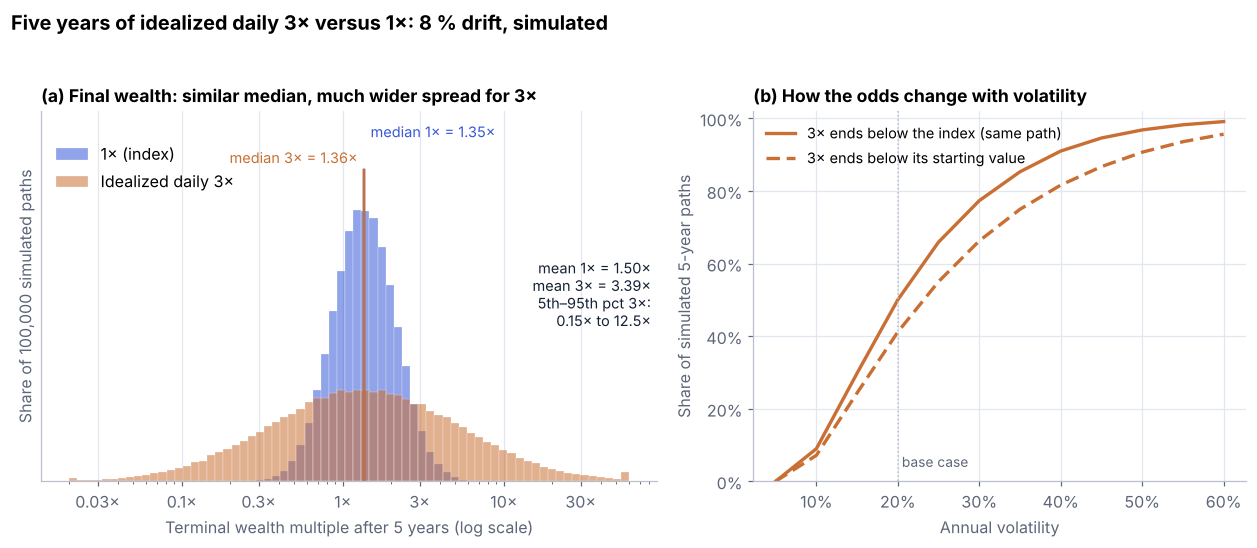

In [13]:
# Probability that the 3× product ends below the index, as volatility varies (drift fixed at 8 %).
sig_grid = np.arange(0.05, 0.6001, 0.05)
p_below_index, p_below_start = [], []
for s in sig_grid:
    Wg, _ = simulate_terminal(0.08, s, 5, n_paths=20_000, seed_seq=_seeds[7])
    p_below_index.append(np.mean(Wg[3] < Wg[1])); p_below_start.append(np.mean(Wg[3] < 1))

# Figure 4
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.8), gridspec_kw={"width_ratios": [1.25, 1]})
bins = np.logspace(np.log10(0.02), np.log10(60), 70)
ax1.hist(W1, bins=bins, color=BLUE, alpha=0.55, label="1× (index)", edgecolor="white", linewidth=0.3)
ax1.hist(np.clip(W3, bins[0], bins[-1] - 1e-9), bins=bins, color=ORANGE, alpha=0.55, label="Idealized daily 3×", edgecolor="white", linewidth=0.3)
ax1.set_xscale("log")
ax1.xaxis.set_major_locator(FixedLocator([0.03, 0.1, 0.3, 1, 3, 10, 30])); ax1.xaxis.set_minor_formatter(NullFormatter())
ax1.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}×"))
ytop = ax1.get_ylim()[1] * 1.30
ax1.set_ylim(0, ytop)
for w, col in ((W1, BLUE), (W3, ORANGE)):
    ax1.plot([np.median(w)] * 2, [0, ytop * 0.84], color=col, lw=1.6)
ax1.text(np.median(W1) * 1.10, ytop * 0.93, f"median 1× = {np.median(W1):.2f}×", color=BLUE, fontsize=9.5, ha="left")
ax1.text(np.median(W3) * 0.91, ytop * 0.86, f"median 3× = {np.median(W3):.2f}×", color=ORANGE, fontsize=9.5, ha="right")
ax1.set_yticks([]); ax1.set_xlabel("Terminal wealth multiple after 5 years (log scale)")
ax1.set_ylabel("Share of 100,000 simulated paths")
ax1.set_title("(a) Final wealth: similar median, much wider spread for 3×")
ax1.legend(loc="upper left", bbox_to_anchor=(0.0, 0.95))
ax1.text(0.99, 0.60, f"mean 1× = {W1.mean():.2f}×\nmean 3× = {W3.mean():.2f}×\n5th–95th pct 3×:\n{np.quantile(W3, .05):.2f}× to {np.quantile(W3, .95):.1f}×",
         transform=ax1.transAxes, ha="right", va="top", fontsize=9.5, color=INK)

ax2.plot(sig_grid, p_below_index, color=ORANGE, label="3× ends below the index (same path)")
ax2.plot(sig_grid, p_below_start, color=ORANGE, ls=(0, (4, 2)), label="3× ends below its starting value")
ax2.axvline(0.20, color="#b9bfcc", lw=1, ls=":"); ax2.text(0.205, 0.04, "base case", fontsize=9, color=MUTED)
ax2.xaxis.set_major_formatter(pct); ax2.yaxis.set_major_formatter(pct); ax2.set_ylim(0, 1.02)
ax2.set_xlabel("Annual volatility"); ax2.set_ylabel("Share of simulated 5-year paths")
ax2.set_title("(b) How the odds change with volatility")
ax2.legend(loc="upper left", fontsize=9.5)
fig.suptitle("Five years of idealized daily 3× versus 1×: 8 % drift, simulated", x=0.01, ha="left", fontsize=13, fontweight="bold", y=1.03)
fig.tight_layout()
save_figure(fig, "04-monte-carlo-terminal-distribution.png",
    alt="Two charts. Left: overlapping histograms on a log scale of five-year terminal wealth for 1× and idealized daily 3× exposure at 20 percent volatility; the medians are nearly the same, but the 3× distribution is much wider, with a long right tail and many outcomes far below the start. Right: lines showing that the probability of the 3× product ending below the index, and below its starting value, rises with annual volatility from 5 to 60 percent.",
    caption="Five-year terminal wealth in a simulation with 8 % arithmetic drift and 20 % volatility: the 1× and 3× medians are close, but the 3× distribution is far wider, and the chance of trailing the index rises steeply with volatility.",
    assumptions="100,000 paths (panel a) and 20,000 paths per volatility level (panel b), i.i.d. Normal daily simple returns, arithmetic mean 8 % a year, 252 days, idealized daily reset, no fees or financing, fixed seeds.")

In [14]:
# Robustness: fat tails. Same mean and variance, Student-t daily shocks with 4 degrees of freedom.
Wt, wiped_t = simulate_terminal(**BASE, seed_seq=_seeds[8], dist="t", df=4, n_paths=50_000)
cmp = pd.DataFrame({
    "Normal 1×": [np.median(W1), W1.mean(), np.mean(W1 < 1)],
    "Normal 3×": [np.median(W3), W3.mean(), np.mean(W3 < 1)],
    "Student-t(4) 1×": [np.median(Wt[1]), Wt[1].mean(), np.mean(Wt[1] < 1)],
    "Student-t(4) 3×": [np.median(Wt[3]), Wt[3].mean(), np.mean(Wt[3] < 1)],
}, index=["Median", "Mean", "P(ends below start)"])
display(cmp.style.format("{:.2f}"))
print("Total-loss paths under Student-t(4): 1×", wiped_t[1], "| 3×", wiped_t[3], "(of 50,000)")

,Normal 1×,Normal 3×,Student-t(4) 1×,Student-t(4) 3×
Median,1.35,1.36,1.35,1.35
Mean,1.50,3.39,1.49,3.35
P(ends below start),0.25,0.41,0.25,0.41


Total-loss paths under Student-t(4): 1× 1 | 3× 102 (of 50,000)


**Interpretation.** In the base case the typical (median) 3× outcome is about the same as the typical index outcome, while the spread is enormous: the 3× distribution has a long right tail and also puts a large share of paths well below the start. The *mean* of the 3× outcome is more than twice the index's (it is $(1+3\mu_d)^T$, exactly), but that mean is carried by rare large outcomes and says little about a typical path. Panel (b) shows why one should not summarize this with a single sentence: with the same drift, quiet markets favour the 3× product and turbulent markets sharply penalize it.

The fat-tail check changes the numbers modestly but not the picture, and total-loss days are counted rather than assumed away.

## 7. A real two-session round trip: QQQ, TQQQ and SQQQ (21 to 25 June 2024)

> **This is one observed example, not statistical evidence and not a simulation.** It shows the compounding mechanism from Section 1 in real prices. It does not say how leveraged ETFs "usually" behave, and it is not a forecast.

**The data.** Three trading dates, committed in the repository as `data/qqq-tqqq-sqqq-2024-06-21-25.csv` (provenance in `data/README.md`):

* the values are Yahoo Finance `Close` as returned by `yfinance` with its then-default auto-adjustment, **recovered from the saved output of the original Colab notebook** `leverage testing.ipynb`;
* the retrieval date was not recorded, and **no fresh retrieval was possible when the snapshot was committed**, so the notebook below reads the committed file and needs no internet access;
* TQQQ targets +3× and SQQQ targets −3× the daily return of the **Nasdaq-100 index**; QQQ is a tradable ETF on that index and is used only as a convenient proxy for it, not as the contractual benchmark.

**Dividend adjustment.** QQQ went ex-dividend on 24 June 2024 ($0.7615 per share), inside the interval. An independently retrieved series of *unadjusted* closes (480.18, 473.96, 479.38) gives a raw price return of about −0.167% from 21 to 25 June, whereas the dividend-adjusted return in the snapshot is about −0.008%. The near-flat QQQ result below is therefore a **dividend-adjusted return statement, not an unadjusted price round trip**. The independent series also matches the TQQQ and SQQQ endpoint returns (about −0.161% and −0.119%); their absolute levels are affected by later split adjustments, which does not matter here because only ratios are used. (See `data/README.md`.)

**Selection caveat.** This sequence was originally located by scanning QQQ history for a short fall-and-rebound, so it is a *selected* example chosen to illustrate the mechanism; it says nothing about how often such sequences occur or how large the effect typically is.

An adjusted close changes *level* depending on when it was retrieved, but the ratios between dates inside this short window are unaffected, and only ratios are used below. Everything is normalized to 100 on 21 June.

In [15]:
SNAPSHOT = REPO_ROOT / "data" / "qqq-tqqq-sqqq-2024-06-21-25.csv"
snap = pd.read_csv(SNAPSHOT, parse_dates=["date"]).set_index("date")
print("Committed snapshot (yfinance Close, auto-adjusted; recovered from the original Colab output):")
display(snap.style.format("{:.6f}"))

norm = 100 * snap / snap.iloc[0]                       # every series starts at 100
daily = snap.pct_change().dropna()                     # day 1: 21 -> 24 June; day 2: 24 -> 25 June
cumulative = snap.iloc[-1] / snap.iloc[0] - 1          # 21 -> 25 June

print("\nNormalized (21 June = 100):")
display(norm.style.format("{:.4f}"))
summary = pd.DataFrame({"Day 1 (21→24 Jun)": daily.iloc[0], "Day 2 (24→25 Jun)": daily.iloc[1],
                        "Cumulative (21→25 Jun)": cumulative}).T
display(summary.style.format("{:+.4%}"))

# Idealized daily rule applied to QQQ's own two daily returns, for context only
ideal_up   = np.prod(1 + 3 * daily["QQQ"].to_numpy()) - 1
ideal_down = np.prod(1 - 3 * daily["QQQ"].to_numpy()) - 1
print(f"\nIdealized +3× / −3× applied to QQQ's two daily returns: {ideal_up:+.4%} / {ideal_down:+.4%}")
print(f"Actual TQQQ / SQQQ:                                     {cumulative['TQQQ']:+.4%} / {cumulative['SQQQ']:+.4%}")

# arithmetic checks against the cumulative returns documented in data/README.md
assert abs(cumulative["QQQ"] - (-0.000079)) < 1e-6 and abs(cumulative["TQQQ"] - (-0.001613)) < 1e-6 and abs(cumulative["SQQQ"] - (-0.001190)) < 1e-6
assert abs(norm.loc["2024-06-24", "TQQQ"] / 100 - 0.966129) < 1e-6 and abs(norm.loc["2024-06-25", "SQQQ"] / 100 - 0.998810) < 1e-6

Committed snapshot (yfinance Close, auto-adjusted; recovered from the original Colab output):


,QQQ,TQQQ,SQQQ
date,,,
2024-06-21 00:00:00,474.442383,36.453793,179.867706
2024-06-24 00:00:00,469.040985,35.219070,186.077438
2024-06-25 00:00:00,474.404816,36.394997,179.653595



Normalized (21 June = 100):


,QQQ,TQQQ,SQQQ
date,,,
2024-06-21 00:00:00,100.0000,100.0000,100.0000
2024-06-24 00:00:00,98.8615,96.6129,103.4524
2024-06-25 00:00:00,99.9921,99.8387,99.8810


,QQQ,TQQQ,SQQQ
Day 1 (21→24 Jun),-1.1385%,-3.3871%,+3.4524%
Day 2 (24→25 Jun),+1.1436%,+3.3389%,-3.4522%
Cumulative (21→25 Jun),-0.0079%,-0.1613%,-0.1190%



Idealized +3× / −3× applied to QQQ's two daily returns: -0.1019% / -0.1325%
Actual TQQQ / SQQQ:                                     -0.1613% / -0.1190%


In [16]:
# Figure 5 (article Figure 2): the real round trip, as an interactive Plotly figure (reads only the committed snapshot).
VIOLET = "#7a4fb3"
colors = {"QQQ": BLUE, "TQQQ": ORANGE, "SQQQ": VIOLET}
names = {"QQQ": "QQQ (index proxy)", "TQQQ": "TQQQ (daily +3×)", "SQQQ": "SQQQ (daily −3×)"}
labels = [f"{d:%b} {d.day}, {d.year}" for d in norm.index]
since_start = 100 * (snap / snap.iloc[0] - 1)                          # exact cumulative return in percent

fig = go.Figure()
for k in ("QQQ", "TQQQ", "SQQQ"):
    fig.add_trace(go.Scatter(
        x=labels, y=norm[k].round(6), mode="lines+markers", name=names[k],
        line=dict(color=colors[k], width=3), marker=dict(size=9),
        customdata=np.column_stack([snap[k].round(2), since_start[k].round(4)]),
        hovertemplate=("<b>%{fullData.name}</b><br>%{x}<br>Adjusted close: %{customdata[0]:.2f}<br>"
                       "Normalized: %{y:.2f}<br>Return since Jun 21: %{customdata[1]:+.4f}%<extra></extra>")))
# direct labels at the last point, offset so the three nearly equal endpoints do not overlap
for k, dy in (("QQQ", 16), ("SQQQ", 0), ("TQQQ", -16)):
    fig.add_annotation(x=labels[-1], y=float(norm[k].iloc[-1]), xref="x", yref="y", xanchor="left", xshift=14, yshift=dy,
                       text=f"<b>{k}</b> {since_start[k].iloc[-1]:+.2f}%".replace("-", "−"), showarrow=False,
                       font=dict(color=colors[k], size=13))
fig.add_hline(y=100, line=dict(color="#b9bfcc", width=1))
fig.update_layout(
    template="none", paper_bgcolor="white", plot_bgcolor="white", height=440, margin=dict(l=64, r=120, t=24, b=56),
    font=dict(family="Inter, system-ui, -apple-system, 'Segoe UI', sans-serif", size=13, color="#142033"),
    legend=dict(orientation="h", x=0, y=1.1, xanchor="left"), hovermode="closest",
    xaxis=dict(title=None, type="category", showgrid=False, linecolor="#b9bfcc"),
    yaxis=dict(title="Value (adjusted close, 21 June = 100)", range=[95.5, 105], tickformat=".0f", gridcolor="#e3e6ee", zeroline=False))
fig.show()
save_plotly(fig, "05-qqq-tqqq-sqqq-roundtrip",
    alt="Line chart of QQQ, TQQQ and SQQQ adjusted closes normalized to 100 on 21 June 2024, for 21, 24 and 25 June. QQQ dips to 98.86 and returns to 99.99, TQQQ dips to 96.61 and ends at 99.84, and SQQQ rises to 103.45 and ends at 99.88. Hovering a point shows the exact date, adjusted close and return since 21 June.",
    caption="A real two-session illustration. On a dividend-adjusted basis, QQQ finished almost exactly at its 21 June level by 25 June, while both the daily +3× product TQQQ and the daily −3× product SQQQ finished slightly below their starting values.",
    assumptions="Historical observed data, not a simulation. Three trading dates (21, 24, 25 June 2024); yfinance Close as auto-adjusted, recovered from the original Colab notebook output; retrieval date not recorded. QQQ went ex-dividend during the interval, so its near-flat result is specifically a dividend-adjusted return statement, not an unadjusted price round trip. Snapshot: data/qqq-tqqq-sqqq-2024-06-21-25.csv. QQQ is a tradable proxy for the Nasdaq-100, which TQQQ and SQQQ target daily; one selected illustration, not statistical evidence. Displayed prices and percentages are rounded to two decimals; hover shows the return to four.")

**What this shows.** On 24 June QQQ fell 1.14 % and on 25 June it rose 1.14 %, ending 0.008 % below its 21 June level on a dividend-adjusted basis: practically a round trip in total-return terms. TQQQ moved about three times as much each day and finished 0.161 % *below* its start; SQQQ, the inverse product, moved the other way each day and *also* finished 0.119 % below its start. That is the compounding effect from Section 1 in real prices: when the underlying reverses direction, a daily-reset product does not undo its first-day move exactly, and this holds for both the long and the inverse version, so it is not a bet on direction going wrong.

The sizes matter. Over two sessions the gap is a fraction of a percent, in line with the small second-order term of Section 2 (it grows with the square of the move and with the number of reversals). The *idealized* daily rule applied to QQQ's own returns gives −0.102 % and −0.132 %, so the actual funds differ by a few hundredths of a percent. Fees, financing, the fact that QQQ is a proxy for the Nasdaq-100 rather than the contractual benchmark, and closing-time effects could all contribute; three data points cannot separate them, and this example does not measure tracking error.

It is **one** observed example, selected because it illustrates the mechanism. It does not show that leveraged ETFs must lose over every sideways period, and it says nothing about long-horizon outcomes.

In [17]:
# Optional validation (never required): compare RETURNS in the committed snapshot with a fresh fetch, if Yahoo Finance is reachable.
def validate_snapshot(snapshot, tolerance_bp=5):
    import logging
    logging.getLogger("yfinance").setLevel(logging.CRITICAL)
    try:
        import yfinance as yf
    except ImportError:
        return print("Validation skipped: yfinance is not installed.")
    try:
        raw = yf.download(list(snapshot.columns), start="2024-06-21", end="2024-06-26", auto_adjust=False, progress=False)
    except Exception as exc:
        return print(f"Validation skipped: download failed ({type(exc).__name__}).")
    if raw is None or len(raw) == 0 or not isinstance(raw.columns, pd.MultiIndex):
        return print("Validation skipped: no data returned (offline or blocked). The committed snapshot is unchanged.")
    for field in ("Close", "Adj Close"):
        fresh = raw[field][list(snapshot.columns)].dropna()
        fresh.index = pd.to_datetime(fresh.index).tz_localize(None)
        fresh = fresh.reindex(snapshot.index)
        if fresh.isna().any().any():
            print(f"{field}: some snapshot dates are missing from the fresh download; skipped."); continue
        diff_bp = 1e4 * ((fresh.iloc[-1] / fresh.iloc[0]) - (snapshot.iloc[-1] / snapshot.iloc[0]))
        print(f"{field}: difference in 21→25 June return, fresh minus snapshot (basis points):")
        print(diff_bp.round(2).to_string())
        print("  within tolerance" if (diff_bp.abs() <= tolerance_bp).all() else "  OUTSIDE tolerance: investigate the data convention")
validate_snapshot(snap)

Validation skipped: yfinance is not installed.


## 8. Limitations

* **Idealized product.** Real leveraged ETFs pay management fees, pay financing costs on swap or margin exposure, can deviate from their daily target (tracking error), face derivative and counterparty constraints, and rebalance at the close with market impact. None of this is in the simulation.
* **i.i.d. returns.** Real returns show volatility clustering, serial dependence, fat tails and jumps. The Student-t check addresses tails only; clustering matters a lot for realized drag and is not modelled.
* **Constant drift and volatility.** The parameters are fixed inputs, not estimates, and long-run drift is notoriously hard to estimate. Volatility and drift are not independent in real markets.
* **Approximations.** The $L\mu - \tfrac12L^2\sigma^2$ growth formula is second-order; it is accurate for moderate $L\sigma_d$ and breaks down for very large moves. Simulated medians are used wherever precision matters.
* **Mean versus median.** Terminal wealth is highly skewed. A sentence like "the leveraged product does better on average" and a sentence like "the leveraged product usually does worse" can both be true at once; neither is advice.
* **One real-data example.** The QQQ/TQQQ/SQQQ round trip is a single three-date observation, with QQQ standing in for the Nasdaq-100 and an adjusted-close convention whose retrieval date was not recorded. It illustrates the mechanism; it is not a test and does not measure tracking error.
* **Investor behaviour, taxes, borrowing costs of a do-it-yourself leveraged portfolio and holding-period choice** are outside the scope.

## 9. Corrections and improvements relative to the source notebooks

| Source | Problem found | What this notebook does instead |
|---|---|---|
| `leverage.ipynb` | **Percent/decimal mix-up in the drift.** Returns are divided by 100 (so inputs are in percent), but the drift for the "simulated S&P 500" case is passed as `1.12 ** (1/365) - 1`, a *decimal* (≈ 0.0003), where percent was expected: the intended 12 % a year became ≈ 0.0003 % a day, about 100× too small. | All returns are simple decimal returns; drift and volatility are annual inputs converted explicitly with 252 trading days. |
| `leverage.ipynb` | `mean_total_returnes(mu, sigma, ...)` **ignores its arguments**: `Normal(mu=0, sigma=1.5)` is hard-coded inside the loop, so changing `mu` or `sigma` changes nothing. | Parameters are used; one function, `simulate_terminal`, takes drift, volatility, horizon and leverage. |
| `leverage.ipynb` | A Python loop with `n_trials=10_000_000`, each calling SciPy's sampler on a 1,095-element array: effectively unrunnable. Horizon `365*3` counts calendar days although markets trade about 252 days a year. | Vectorized NumPy in chunks, summarized without storing all paths; 252 trading days a year. |
| `leverage.ipynb` | Unseeded randomness, so every figure changes on each run. The title mixes a single simulated path with an implied general claim. | Fixed seeds via `SeedSequence`; the single path is always shown next to a median over thousands of paths. |
| `leverage.ipynb` | Only the arithmetic mean daily return is specified; there is no distinction between average return and compound growth. | Section 4 separates arithmetic mean, geometric growth and the volatility-drag term; Section 5 gives the approximation and its break-even conditions. |
| `leverage.ipynb` | `sc.stats.Normal(...)` (a recent SciPy API) and plotly's pandas backend are used for what is a few lines of NumPy. | NumPy `default_rng`; Matplotlib for static, exportable figures. |
| `leverage-testing.ipynb` | **Selection bias.** The notebook scans five years of QQQ prices for the three-day "loss then return to the original price" sequence that fits best, then uses it as an example. | Section 1 uses a clean synthetic example with a closed form. Section 7 keeps the original notebook's real QQQ/TQQQ/SQQQ round trip, but as one committed, fully documented three-date snapshot that is explicitly labelled a *selected illustration* (it was found by a search), not evidence. |
| `leverage-testing.ipynb` | `(prices / prices.shift(1)).cumprod()` leaves a leading NaN, and the comparison is on raw `Close` columns whose meaning changed in recent `yfinance` (auto-adjustment on by default; MultiIndex columns even for one ticker). | The real example is a committed CSV snapshot with its price convention documented, normalized to 100, and an optional validation cell that handles the current `yfinance` MultiIndex layout and never fails offline. |
| `leverage-testing.ipynb` | Raw share prices are plotted together although TQQQ and QQQ trade on different scales and TQQQ has been split. | Only normalized total-return series are compared. |
| `leverage-and-origin-weighting.ipynb` | `pd.concat` of two `yf.download` frames and a hard-coded `df.columns = ['ticker', 'leverage']` **break with the MultiIndex columns** returned by current `yfinance`; no check that the two products have overlapping dates (fund inception dates differ); no leverage factor, fee or product-structure information. | Not reused (see below). The fetch/overlap logic in the validation cell in Section 7 shows the safer pattern. |

## 10. What was deliberately not used

`leverage-and-origin-weighting.ipynb` pairs single stocks, crypto products and index ETFs with their leveraged counterparts and then plots a **daily-rebalanced blend** of the underlying and the leveraged product. That is a different question (what happens when you *combine* a leveraged and an unleveraged position, which is equivalent to an intermediate leverage factor), and the pairs have different leverage targets (2× vs 3×), inception dates, fees and structures. Folding it into this first article would dilute the core mechanism and invite exactly the cross-asset comparisons that need more careful data work. **Recommendation:** treat it as material for a follow-up article on blending leveraged and unleveraged exposure, built on Section 5's growth formula, with a vetted pair list that records each fund's leverage factor, inception date and expense ratio.

## 11. Key points for the article

1. A daily $L\times$ product multiplies each day's return by $L$; over longer horizons the result is **not** $L$ times the index's cumulative return, because percentage changes compound on a changing base.
2. The two-day example $1 - L(L-1)a^2/(1-a)$ makes this exact, and shows that the shortfall grows with the **square** of the move.
3. Across paths, the leveraged outcome depends on the route, not only on where the index ends.
4. Volatility drag is the difference between arithmetic and compound returns, about $\sigma^2/2$ for the index and $L^2\sigma^2/2$ for the leveraged product. The *drift* is multiplied by $L$, the *drag* by $L^2$.
5. This is **not** "leveraged ETFs always decay": with the same drift, 3× wins at low volatility, roughly ties near $\mu = 2\sigma^2$, and loses at high volatility.
6. Terminal wealth is highly skewed, so mean, median and the chance of ending below the start tell different stories.
7. Everything here is idealized: real funds add fees, financing and tracking differences.

In [18]:
# Write a manifest of exported figures (file, alt text, caption idea, assumptions) next to the images.
if EXPORT_FIGURES and MANIFEST:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    (FIG_DIR / "figures.json").write_text(json.dumps(MANIFEST, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
print("Exported figures:")
for name, meta in MANIFEST.items():
    print(f"  {meta.get('file') or meta['spec']}")

Exported figures:
  figures/01-two-day-example.png
  figures/02-same-index-different-paths.png
  figures/03-volatility-comparison.png
  figures/06-growth-rate-vs-leverage.png
  figures/04-monte-carlo-terminal-distribution.png
  figures/05-qqq-tqqq-sqqq-roundtrip.json
